In [1]:
import processing as pr

In [2]:
# 1. Extract data
data_arena = pr.process_results_csv(MAP_NAME="arena", BATCHES=[0, 5, 10, 20, 35, 50], PREFIX="./arena/")
data_denver = pr.process_results_csv(MAP_NAME="Denver_1_256", BATCHES=[0, 50, 150, 320], PREFIX="./Denver_1_256/")
data_empty = pr.process_results_csv(MAP_NAME="empty_64_64", BATCHES=[0, 5, 10, 20, 50, 80], PREFIX="./empty_64_64/")

[Processing] Aggregating CSVs for map 'arena' from ./arena/
[Processing] Aggregating CSVs for map 'Denver_1_256' from ./Denver_1_256/
[Processing] Aggregating CSVs for map 'empty_64_64' from ./empty_64_64/


[Thumbnails] Generating map snapshots for arena...
  -> Saved ./arena//arena_random_0.png
  -> Saved ./arena//arena_random_5.png
  -> Saved ./arena//arena_random_10.png
  -> Saved ./arena//arena_random_20.png
  -> Saved ./arena//arena_random_35.png
  -> Saved ./arena//arena_random_50.png
[Plotting] Saved ../media/arena_random_runtime.png


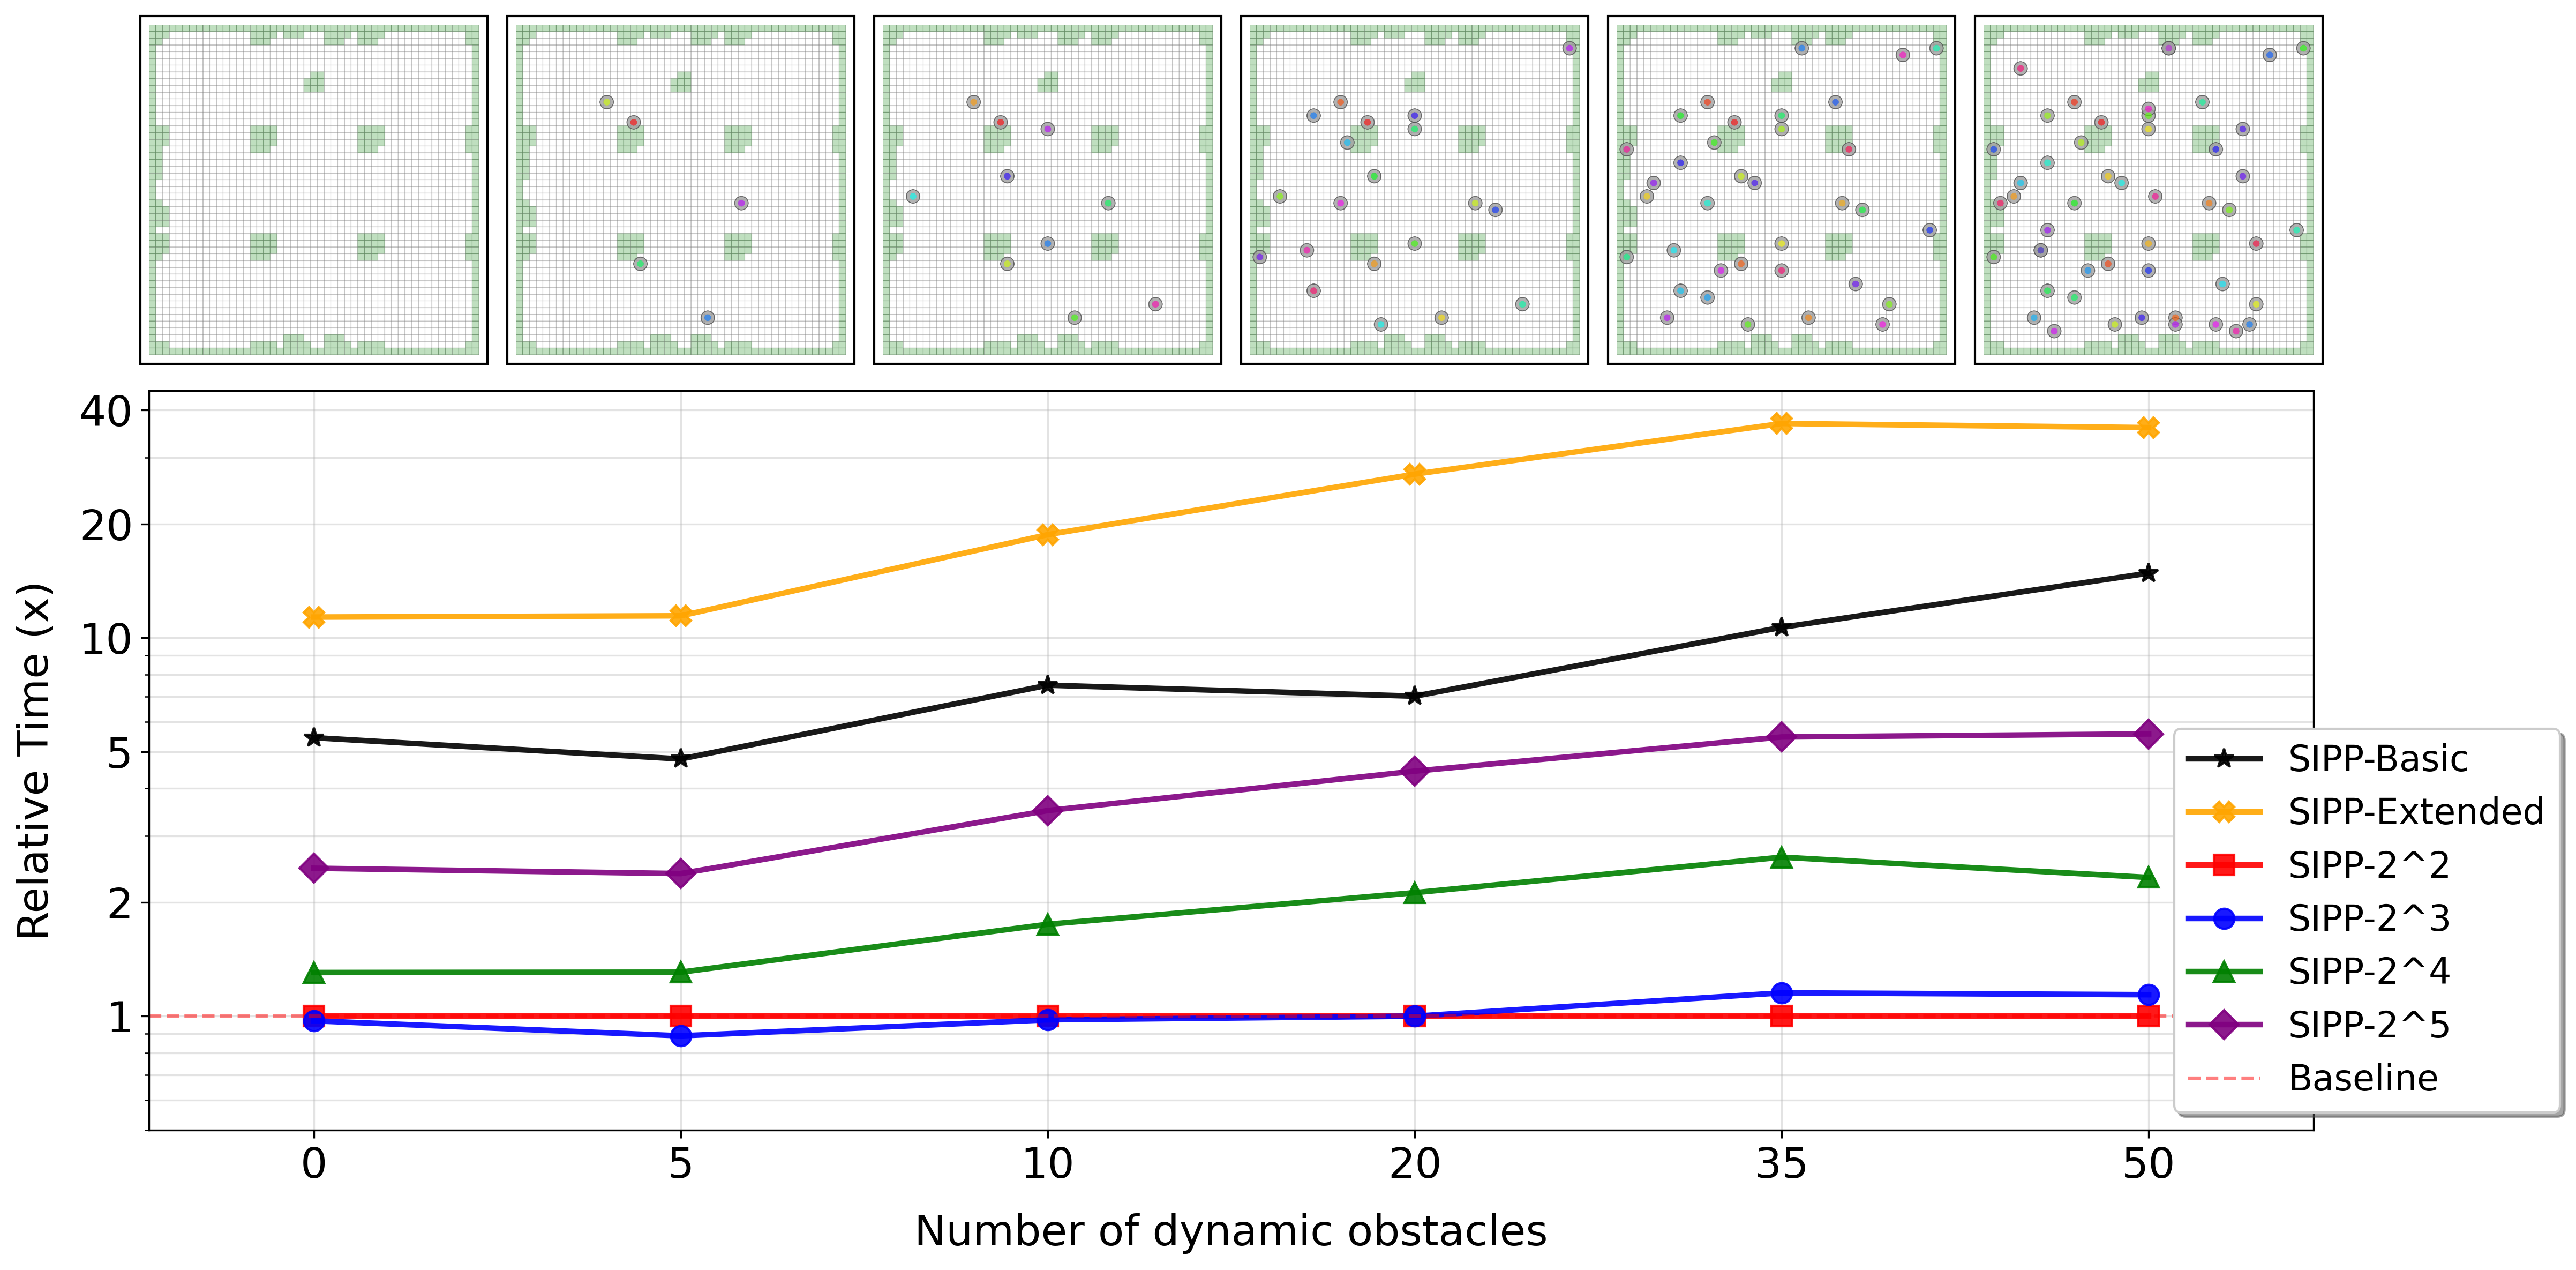

[Thumbnails] Generating map snapshots for Denver_1_256...
  -> Saved ./Denver_1_256//Denver_1_256_random_0.png
  -> Saved ./Denver_1_256//Denver_1_256_random_50.png
  -> Saved ./Denver_1_256//Denver_1_256_random_150.png
  -> Saved ./Denver_1_256//Denver_1_256_random_320.png
[Plotting] Saved ../media/Denver_1_256_random_runtime.png


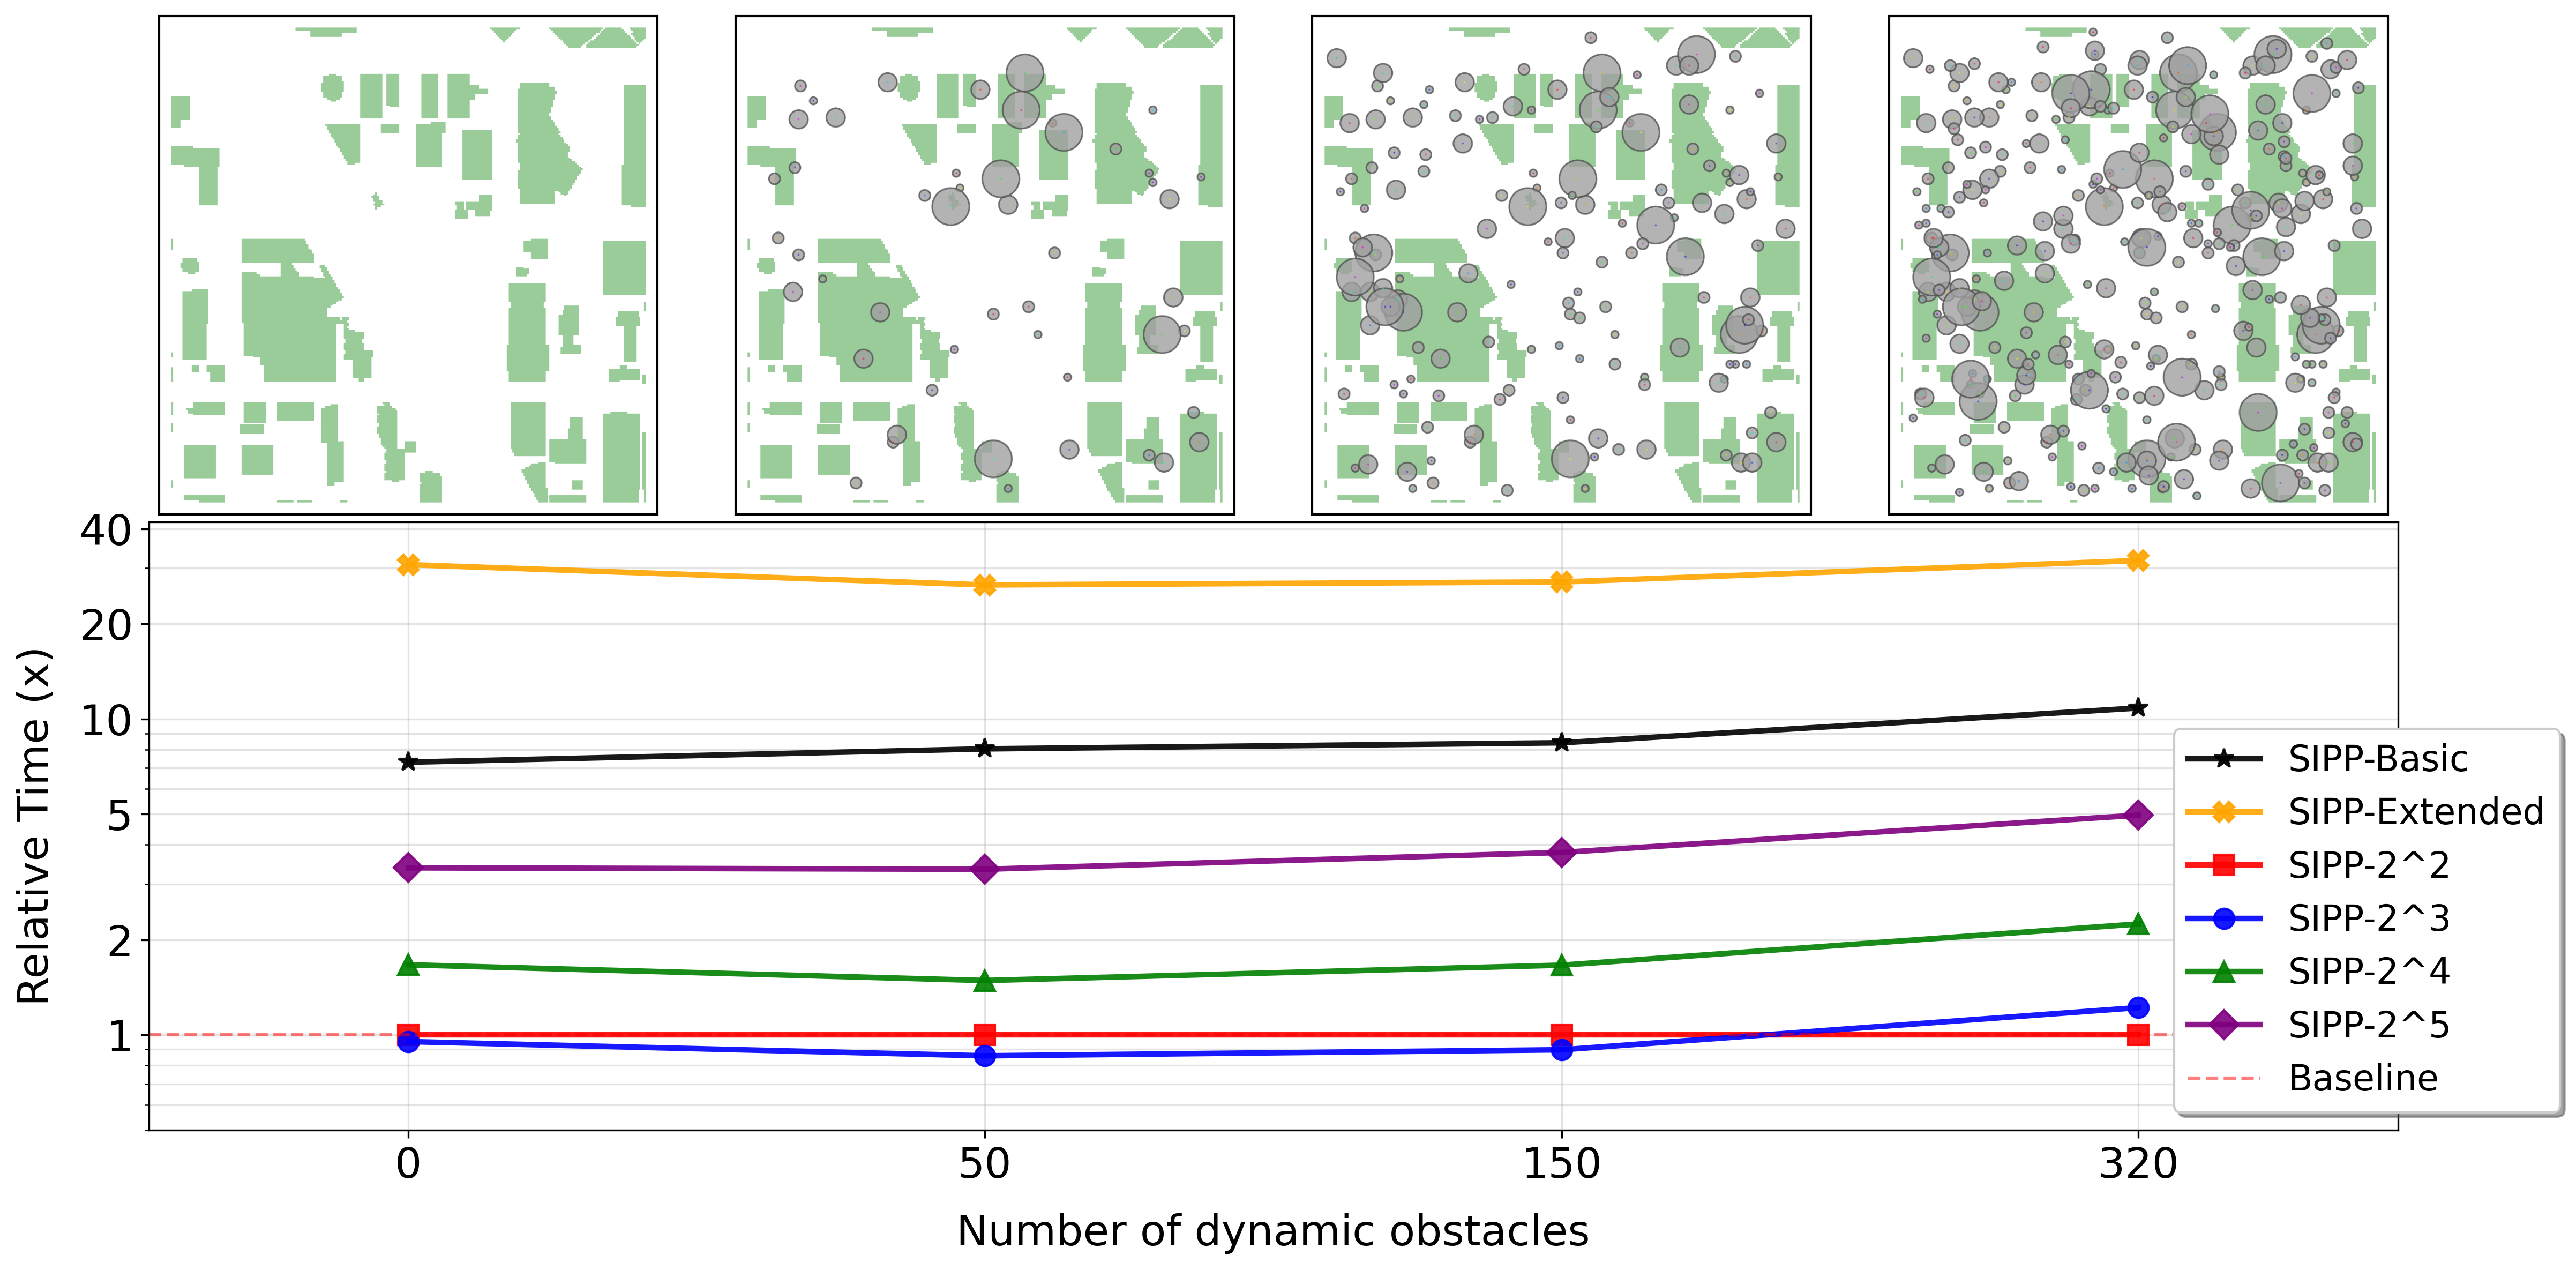

[Thumbnails] Generating map snapshots for empty_64_64...
  -> Saved ./empty_64_64//empty_64_64_circle_0.png
  -> Saved ./empty_64_64//empty_64_64_circle_5.png
  -> Saved ./empty_64_64//empty_64_64_circle_10.png
  -> Saved ./empty_64_64//empty_64_64_circle_20.png
  -> Saved ./empty_64_64//empty_64_64_circle_50.png
  -> Saved ./empty_64_64//empty_64_64_circle_80.png
[Plotting] Saved ../media/empty_64_64_circle_runtime.png


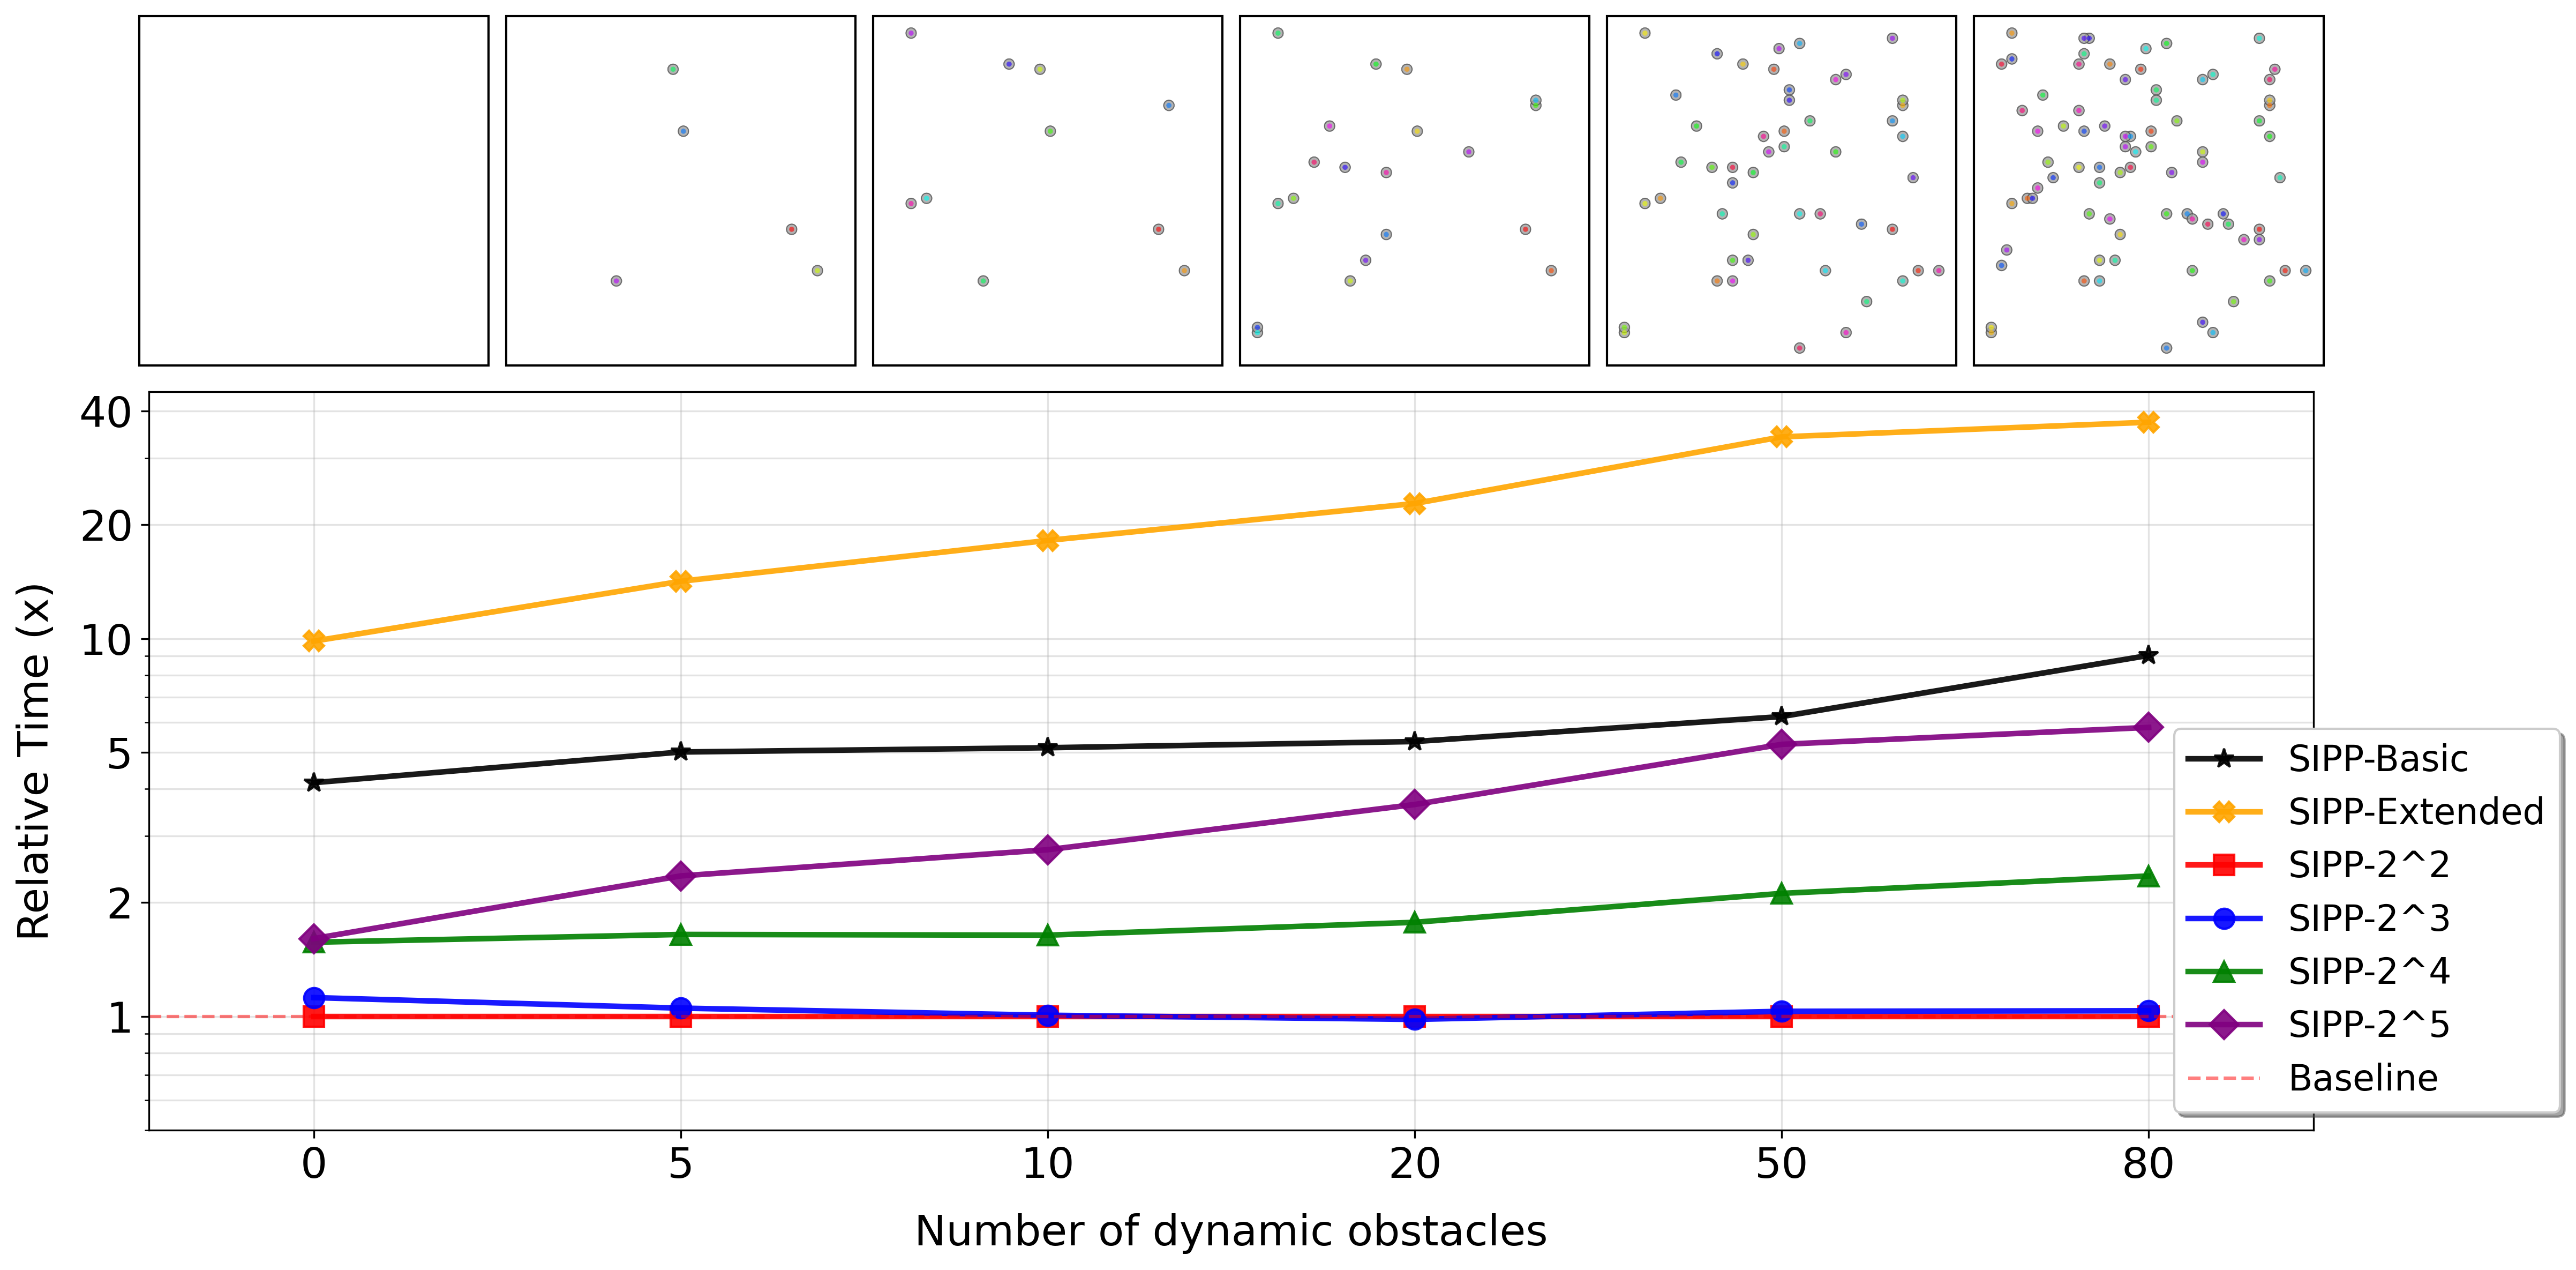

In [3]:
# 2. Plot runtime with map thumbnails

pr.runtime_plot_with_thumbnails(
    data_arena,
    map_name="arena", 
    obs_type="random", 
    prefix="./arena/", 
    obs_batches=[0, 5, 10, 20, 35, 50],
    plot_prefix="../media/"
)

pr.runtime_plot_with_thumbnails(
    data_denver,
    map_name="Denver_1_256", 
    obs_type="random", 
    prefix="./Denver_1_256/", 
    obs_batches=[0, 50, 150, 320],
    fast_draw=True,  # Denver_1_256 is too big -> use fast_draw option
    plot_prefix="../media/",
    image_zoom=0.23,
    ylim_top=42,
    xybox=(0, 115),
    bbox_to_anchor=(1.08, 0)
)

pr.runtime_plot_with_thumbnails(
    data_empty,
    map_name="empty_64_64", 
    obs_type="circle", 
    prefix="./empty_64_64/", 
    obs_batches=[0, 5, 10, 20, 50, 80],
    fast_draw=True,  # To delete grid axis from empty map
    plot_prefix="../media/",
    image_zoom=0.16,
)

In [4]:
# 3. Print heatmaps
pr.print_heatmap_table(data_denver['cost'],      "Median Cost (Relative to Baseline)")
pr.print_heatmap_table(data_denver['curvature'], "Median Curvature (Relative to Baseline)")
pr.print_heatmap_table(data_denver['heading'],   "Median Heading Change (Relative to Baseline)")
pr.print_heatmap_table(data_denver['energy'],    "Median Bending Energy (Relative to Baseline)")


>>> Median Cost (Relative to Baseline)
 obstacles   SIPP-Basic SIPP-Extended     SIPP-2^2     SIPP-2^3     SIPP-2^4     SIPP-2^5
         0    0.813x       0.782x       1.000x       0.826x       0.791x       0.782x   
        50    0.821x       0.787x       1.000x       0.829x       0.795x       0.786x   
       150    0.835x       0.796x       1.000x       0.830x       0.792x       0.787x   
       320    0.896x       0.811x       1.000x       0.854x       0.814x       0.803x   

>>> Median Curvature (Relative to Baseline)
 obstacles   SIPP-Basic SIPP-Extended     SIPP-2^2     SIPP-2^3     SIPP-2^4     SIPP-2^5
         0    0.123x       0.100x       1.000x       0.401x       0.155x       0.076x   
        50    0.168x       0.144x       1.000x       0.479x       0.201x       0.110x   
       150    0.174x       0.159x       1.000x       0.505x       0.223x       0.137x   
       320    0.204x       0.223x       1.000x       0.542x       0.312x       0.205x   

>>> Median Heading Cha

In [5]:
# 4. Export to LaTeX for the paper
latex_code = pr.generate_latex_blocks(data_denver['cost'], "Comparison of Path Costs")
print(latex_code)

\begin{table}[h!]
\centering
\caption{Comparison of Path Costs}
\setlength{\tabcolsep}{8pt}
\renewcommand{\arraystretch}{1.5}
\arrayrulecolor{white}
\setlength{\arrayrulewidth}{2pt}
\begin{tabular}{r | c | c | c | c | c | c}
\toprule
\rowcolor{white} Obstacles & SIPP-Basic & SIPP-Extended & SIPP-2\string^2 & SIPP-2\string^3 & SIPP-2\string^4 & SIPP-2\string^5 \\ \hline
\rowcolor{white} 0 & \cellcolor[HTML]{FF8C32}\color{black}0.813x & \cellcolor[HTML]{21DC32}\color{black}0.782x & \cellcolor[HTML]{FF0032}\color{black}1.000x & \cellcolor[HTML]{FF6A32}\color{black}0.826x & \cellcolor[HTML]{D2DC32}\color{black}0.791x & \cellcolor[HTML]{00DC32}\color{black}0.782x \\ \hline
\rowcolor{white} 50 & \cellcolor[HTML]{FF7E32}\color{black}0.821x & \cellcolor[HTML]{31DC32}\color{black}0.787x & \cellcolor[HTML]{FF0032}\color{black}1.000x & \cellcolor[HTML]{FF6C32}\color{black}0.829x & \cellcolor[HTML]{D3DC32}\color{black}0.795x & \cellcolor[HTML]{00DC32}\color{black}0.786x \\ \hline
\rowcolor{white} 

## Merging Results into a Single LaTeX Table

To save space and improve readability in the final paper, we avoid generating four separate tables. Instead, the function below takes the raw LaTeX strings of the individual metrics (Cost, Curvature, Heading, Energy) and merges them into a single, unified table. 

It automatically extracts the data rows and groups them under full-width gray section headers based on the original table captions.

Note: here we process data only for Denver_1_256 map, but it can be done similarly for others.

In [6]:
import re

def merge_latex_tables(latex_content):
    """
    Parses multiple individual LaTeX tables from a single string and merges 
    them into one unified table with grouped section headers.
    
    Args:
        latex_content (str): A string containing multiple \\begin{table}...\\end{table} blocks.
        
    Returns:
        str: The unified LaTeX table code.
    """
    # 1. Find all individual table blocks within the provided string
    table_blocks = re.findall(r'\\begin\{table\}.*?\\end\{table\}', latex_content, re.DOTALL)
    
    parsed_tables = []
    for block in table_blocks:
        # Extract the metric name from the caption (grabbing the text after the colon)
        caption_match = re.search(r'\\caption\{.*?: (.*?)\}', block)
        caption = caption_match.group(1).strip() if caption_match else "Metric"
        
        # Extract data rows (we identify them by the \rowcolor{white} tag)
        rows = re.findall(r'(\\rowcolor\{white\}\s*\d+.*?)\\\\', block)
        if rows:
            parsed_tables.append((caption, rows))

    if not parsed_tables:
        print("❌ No tables found! Check the input format.")
        return ""

    # 2. Construct the unified LaTeX code
    # Define the global header (7 columns: 1 for obstacles + 6 for algorithms)
    header = r"""\begin{table}[h!]
\centering
\caption{Merged Benchmark Results for \texttt{Denver\_1\_256} map}
\setlength{\tabcolsep}{8pt}
\renewcommand{\arraystretch}{1.2}
\arrayrulecolor{white}
\setlength{\arrayrulewidth}{2pt}
\begin{tabular}{r | c | c | c | c | c | c}
\toprule
\rowcolor[HTML]{F2F2F2} Obstacles & SIPP-B & SIPP-E & SIPP-2$^2$ & SIPP-2$^3$ & SIPP-2$^4$ & SIPP-2$^5$ \\ \hline"""

    body = ""
    for metric, rows in parsed_tables:
        # Insert a segment separator: a full-width gray row with the extracted metric name
        body += f"\n\\rowcolor[HTML]{{EFEFEF}} \\multicolumn{{7}}{{l}}{{\\textbf{{{metric}}}}} \\\\ \\hline"
        
        # Append the extracted data rows for this specific metric
        for row in rows:
            body += f"\n{row} \\\\ \\hline"

    footer = r"""
\bottomrule
\end{tabular}
\end{table}"""

    final_result = header + body + footer
    return final_result


# --- Execution Example ---

# 1. Generate the individual LaTeX blocks and concatenate them into one large string
raw_latex_string = "\n".join([
    pr.generate_latex_blocks(data_denver['cost'], r"\texttt{Denver_1_256}: Path Cost"),
    pr.generate_latex_blocks(data_denver['curvature'], r"\texttt{Denver_1_256}: Trajectory Angularity"),
    pr.generate_latex_blocks(data_denver['heading'], r"\texttt{Denver_1_256}: Angle-Over-Length"),
    pr.generate_latex_blocks(data_denver['energy'], r"\texttt{Denver_1_256}: Bending Energy")
])


# 2. Process the combined string
merged_latex_code = merge_latex_tables(raw_latex_string)

# 3. Print the final result to copy into your paper
print(merged_latex_code)

\begin{table}[h!]
\centering
\caption{Merged Benchmark Results for \texttt{Denver\_1\_256} map}
\setlength{\tabcolsep}{8pt}
\renewcommand{\arraystretch}{1.2}
\arrayrulecolor{white}
\setlength{\arrayrulewidth}{2pt}
\begin{tabular}{r | c | c | c | c | c | c}
\toprule
\rowcolor[HTML]{F2F2F2} Obstacles & SIPP-B & SIPP-E & SIPP-2$^2$ & SIPP-2$^3$ & SIPP-2$^4$ & SIPP-2$^5$ \\ \hline
\rowcolor[HTML]{EFEFEF} \multicolumn{7}{l}{\textbf{Path Cost}} \\ \hline
\rowcolor{white} 0 & \cellcolor[HTML]{FF8C32}\color{black}0.813x & \cellcolor[HTML]{21DC32}\color{black}0.782x & \cellcolor[HTML]{FF0032}\color{black}1.000x & \cellcolor[HTML]{FF6A32}\color{black}0.826x & \cellcolor[HTML]{D2DC32}\color{black}0.791x & \cellcolor[HTML]{00DC32}\color{black}0.782x  \\ \hline
\rowcolor{white} 50 & \cellcolor[HTML]{FF7E32}\color{black}0.821x & \cellcolor[HTML]{31DC32}\color{black}0.787x & \cellcolor[HTML]{FF0032}\color{black}1.000x & \cellcolor[HTML]{FF6C32}\color{black}0.829x & \cellcolor[HTML]{D3DC32}\color{blac